José Matheus Gonçalves Rodrigues - 2171 - GEC

Exercício 1

Coeficiente real: 3
Coeficiente estimado (â): 2.937
Intercepto real: 2
Intercepto estimado (b̂): 2.065


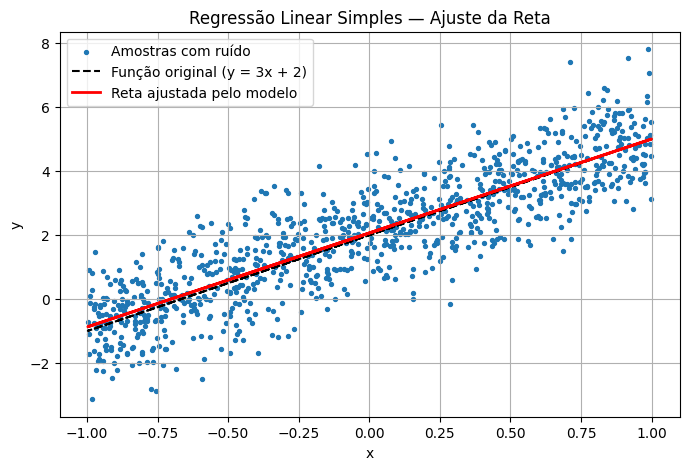

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Gerando os dados
N = 1000                         # Número de amostras
x = np.random.uniform(-1, 1, N).reshape(N, 1)
w = np.random.randn(N, 1)

y = 3*x + 2                           # Função original
y_noisy = y + w                           # Função ruidosa

# 2. Criando o modelo de Regressão Linear
model = LinearRegression()

# 3. Treinando o modelo com os dados ruidosos
model.fit(x, y_noisy)

# 4. Obtendo parâmetros estimados
a_hat = model.coef_[0][0]       # Inclinação
b_hat = model.intercept_[0]     # Intercepto

print("Coeficiente real: 3")
print(f"Coeficiente estimado (â): {a_hat:.3f}")
print("Intercepto real: 2")
print(f"Intercepto estimado (b̂): {b_hat:.3f}")

# 5. Predição nos mesmos pontos
y_pred = model.predict(x)

# 6. Visualização do resultado
plt.figure(figsize=(8,5))
plt.scatter(x, y_noisy, s=8, label="Amostras com ruído")
plt.plot(x, y, 'k--', label="Função original (y = 3x + 2)")
plt.plot(x, y_pred, 'r', linewidth=2, label="Reta ajustada pelo modelo")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão Linear Simples — Ajuste da Reta")
plt.legend()
plt.grid(True)
plt.show()


Exercício 2

Coeficiente real: -3000
Coeficiente estimado (â): -2977.221
Intercepto real: 50000
Intercepto estimado (b̂): 49871.777


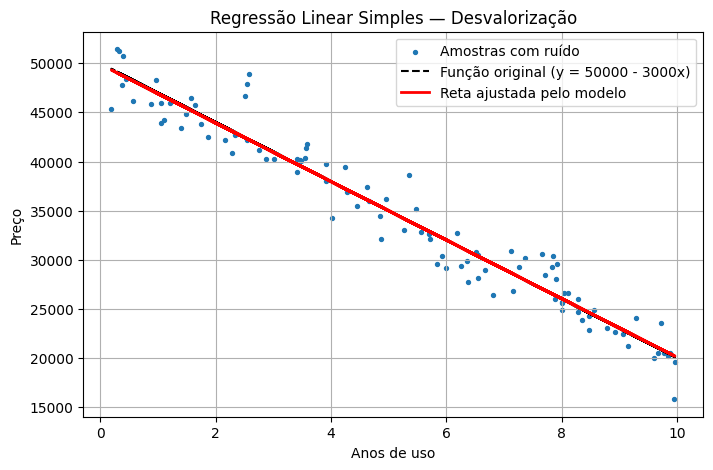

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Gerando os dados
N = 100                         # Número de amostras
x = np.random.uniform(0, 10, N).reshape(N, 1)
w = 2000 * np.random.randn(N, 1)

y = 50000 - 3000*x                           # Função original
y_noisy = y + w                           # Função ruidosa

# 2. Criando o modelo de Regressão Linear
model = LinearRegression()

# 3. Treinando o modelo com os dados ruidosos
model.fit(x, y_noisy)

# 4. Obtendo parâmetros estimados
a_hat = model.coef_[0][0]       # Inclinação
b_hat = model.intercept_[0]     # Intercepto

print("Coeficiente real: -3000")
print(f"Coeficiente estimado (â): {a_hat:.3f}")
print("Intercepto real: 50000")
print(f"Intercepto estimado (b̂): {b_hat:.3f}")

# 5. Predição nos mesmos pontos
y_pred = model.predict(x)

# 6. Visualização do resultado
plt.figure(figsize=(8,5))
plt.scatter(x, y_noisy, s=8, label="Amostras com ruído")
plt.plot(x, y, 'k--', label="Função original (y = 50000 - 3000x)")
plt.plot(x, y_pred, 'r', linewidth=2, label="Reta ajustada pelo modelo")

plt.xlabel("Anos de uso")
plt.ylabel("Preço")
plt.title("Regressão Linear Simples — Desvalorização")
plt.legend()
plt.grid(True)
plt.show()


Exercício 3

Intercepto real: 5
Intercepto estimado (b̂): 5.010399088979607
Coeficientes reais: [3, -2]
Coeficientes estimados (â): [ 2.99228208 -1.96301814]


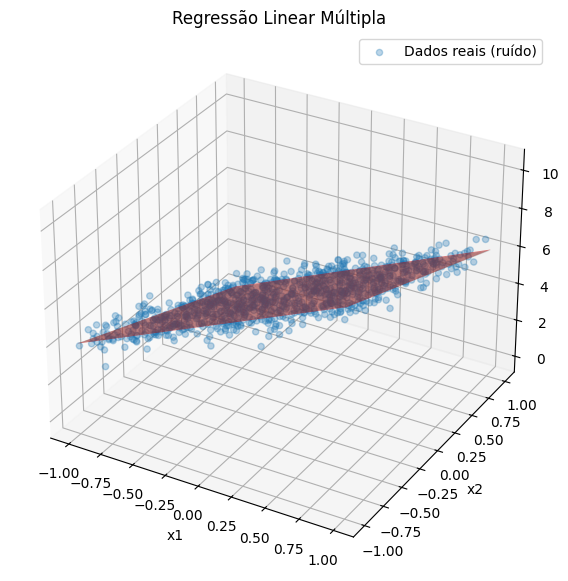

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Gerando os dados
N = 1000

# Duas variáveis de entrada
x1 = np.random.uniform(-1, 1, N)
x2 = np.random.uniform(-1, 1, N)

# Junta em uma matriz (N x 2)
X = np.column_stack((x1, x2))

# Função original
y = 5 + 3*x1 - 2*x2

# Ruído
w = 0.5 * np.random.randn(N)
y_noisy = y + w

# 2. Modelo
model = LinearRegression()

# 3. Treinamento
model.fit(X, y_noisy)

# 4. Parâmetros estimados
b_hat = model.intercept_
a_hat = model.coef_

print("Intercepto real: 5")
print("Intercepto estimado (b̂):", b_hat)
print("Coeficientes reais: [3, -2]")
print("Coeficientes estimados (â):", a_hat)

# 5. Predição
y_pred = model.predict(X)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_noisy, alpha=0.3, label="Dados reais (ruído)")

# Criando um grid para o plano
x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(x1), max(x1), 40),
    np.linspace(min(x2), max(x2), 40))

# Plano original
y_grid_original = 5 + 3*x1_grid - 2*x2_grid

# Plano previsto
y_grid = (b_hat
    + a_hat[0] * x1_grid
    + a_hat[1] * x2_grid)

# Superfície do plano original
ax.plot_surface(x1_grid, x2_grid, y_grid_original, alpha=0.3, color='gray')

# Superfície do plano estimado
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5, color='red')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Regressão Linear Múltipla")
plt.legend()
plt.show()


Exercício 4

Sem normalização
Intercepto real: 0
Intercepto estimado (b̂): -0.43608273858538027
Coeficientes reais: [4, 0.002]
Coeficientes estimados (â): [3.99864899e+00 2.14033074e-03]


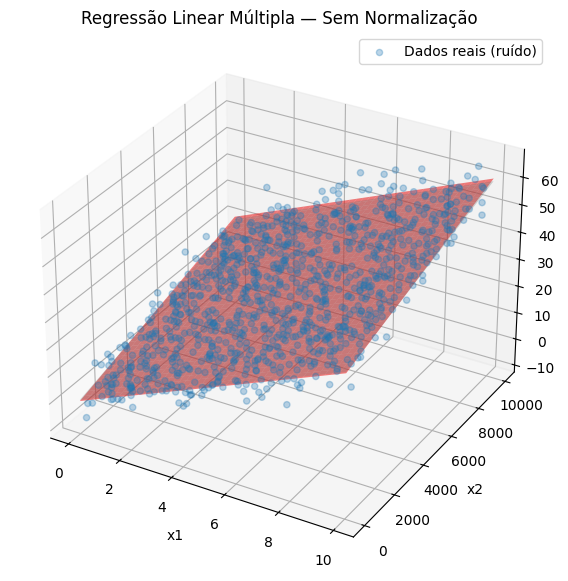


Com normalização
Intercepto estimado (b̂): 29.550353153143146
Coeficientes estimados (â): [11.63106753  6.20559713]


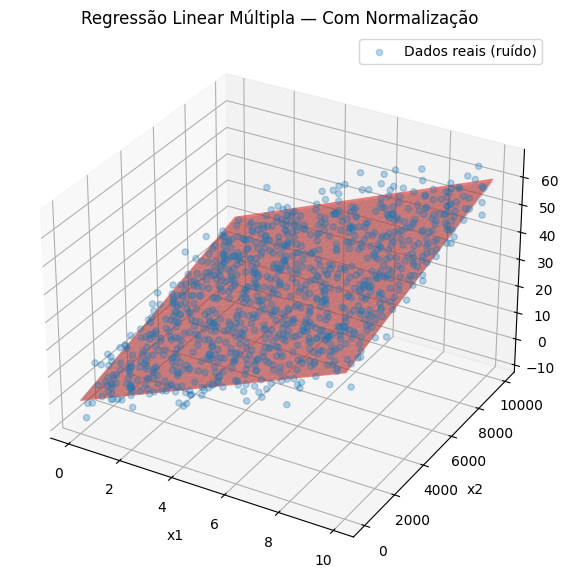

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Gerando os dados
N = 1000

# Duas variáveis de entrada
x1 = np.random.uniform(0, 10, N)
x2 = np.random.uniform(0, 10000, N)

# Junta em uma matriz (N x 2)
X = np.column_stack((x1, x2))

# Função original
y = 4*x1 + 0.002*x2

# Ruído
w = 5 * np.random.randn(N)
y_noisy = y + w

# 2. Modelo sem normalização
model = LinearRegression()

# 3. Treinamento sem normalização
model.fit(X, y_noisy)

# 4. Parâmetros estimados sem normalização
b_hat = model.intercept_
a_hat = model.coef_

print("Sem normalização")
print("Intercepto real: 0")
print("Intercepto estimado (b̂):", b_hat)
print("Coeficientes reais: [4, 0.002]")
print("Coeficientes estimados (â):", a_hat)

# 5. Predição sem normalização
y_pred = model.predict(X)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_noisy, alpha=0.3, label="Dados reais (ruído)")

# Criando um grid para o plano
x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(x1), max(x1), 40),
    np.linspace(min(x2), max(x2), 40))

# Plano original
y_grid_original = 4*x1_grid + 0.002*x2_grid

# Plano previsto sem normalização
y_grid = (b_hat
    + a_hat[0] * x1_grid
    + a_hat[1] * x2_grid)

# Superfície do plano original
ax.plot_surface(x1_grid, x2_grid, y_grid_original, alpha=0.3, color='gray')

# Superfície do plano estimado
ax.plot_surface(x1_grid, x2_grid, y_grid, alpha=0.5, color='red')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Regressão Linear Múltipla — Sem Normalização")
plt.legend()
plt.show()

# 6. Normalização dos dados
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# 7. Modelo com normalização
model_norm = LinearRegression()

# 8. Treinamento com dados normalizados
model_norm.fit(X_norm, y_noisy)

# 9. Parâmetros estimados com normalização
b_hat_norm = model_norm.intercept_
a_hat_norm = model_norm.coef_

print("\nCom normalização")
print("Intercepto estimado (b̂):", b_hat_norm)
print("Coeficientes estimados (â):", a_hat_norm)

# 10. Predição com normalização
y_pred_norm = model_norm.predict(X_norm)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_noisy, alpha=0.3, label="Dados reais (ruído)")

# Normalizando os pontos do grid para usar no modelo normalizado
grid_original = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
grid_norm = scaler.transform(grid_original)

# Plano previsto com normalização
y_grid_norm = model_norm.predict(grid_norm).reshape(x1_grid.shape)

# Superfície do plano original
ax.plot_surface(x1_grid, x2_grid, y_grid_original, alpha=0.3, color='gray')

# Superfície do plano estimado com normalização
ax.plot_surface(x1_grid, x2_grid, y_grid_norm, alpha=0.5, color='red')
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Regressão Linear Múltipla — Com Normalização")
plt.legend()
plt.show()
#A normalização altera a escala das variáveis de entrada. Por isso, os coeficientes do modelo normalizado não devem ser comparados diretamente com 4 e 0.002. Eles indicam o efeito de cada variável depois da padronização.


Exercício 5

Modelo grau 1
Intercepto estimado (b̂): [1.67597875]
Coeficientes estimados (â): [[ 0.         -1.03211246]]

Modelo grau 2
Intercepto estimado (b̂): [0.99371055]
Coeficientes estimados (â): [[ 0.         -1.02210357  2.03728419]]

Modelo grau 3
Intercepto estimado (b̂): [0.99257883]
Coeficientes estimados (â): [[ 0.         -1.150432    2.03998797  0.20956672]]


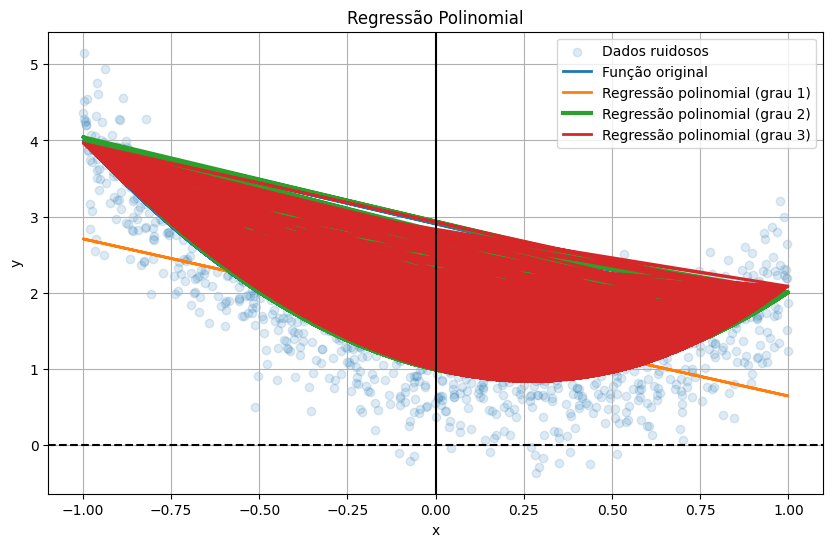


Interpretação:
O modelo de grau 1 apresenta underfitting, pois tenta ajustar uma reta a uma função quadrática.
O modelo de grau 2 é o modelo correto, pois a função real é y = 2x² - x + 1.
O modelo de grau 3 também consegue ajustar bem, mas possui um termo extra desnecessário.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Dados artificiais
N = 1000
x = np.random.uniform(-1, 1, N).reshape(-1, 1)

# Ruído
w = 0.5 * np.random.randn(N, 1)

# Função original: y = 2x² - x + 1
y = 2*(x**2) - x + 1

# Dados com ruído
y_noisy = y + w

# 2. Transformação polinomial (grau 1)
poly1 = PolynomialFeatures(degree=1, include_bias=True)
X_poly1 = poly1.fit_transform(x)

# 3. Treinamento grau 1
model1 = LinearRegression()
model1.fit(X_poly1, y_noisy)

# 4. Predição grau 1
y_pred1 = model1.predict(X_poly1)

# 5. Transformação polinomial (grau 2)
poly2 = PolynomialFeatures(degree=2, include_bias=True)
X_poly2 = poly2.fit_transform(x)

# 6. Treinamento grau 2
model2 = LinearRegression()
model2.fit(X_poly2, y_noisy)

# 7. Predição grau 2
y_pred2 = model2.predict(X_poly2)

# 8. Transformação polinomial (grau 3)
poly3 = PolynomialFeatures(degree=3, include_bias=True)
X_poly3 = poly3.fit_transform(x)   # vira [1, x, x², x³]

# 9. Treinamento grau 3
model3 = LinearRegression()
model3.fit(X_poly3, y_noisy)

# 10. Predição grau 3
y_pred3 = model3.predict(X_poly3)

print("Modelo grau 1")
print("Intercepto estimado (b̂):", model1.intercept_)
print("Coeficientes estimados (â):", model1.coef_)

print("\nModelo grau 2")
print("Intercepto estimado (b̂):", model2.intercept_)
print("Coeficientes estimados (â):", model2.coef_)

print("\nModelo grau 3")
print("Intercepto estimado (b̂):", model3.intercept_)
print("Coeficientes estimados (â):", model3.coef_)

# 11. Plot
plt.figure(figsize=(10,6))
plt.scatter(x, y_noisy, alpha=0.15, label="Dados ruidosos")
plt.plot(x, y, label="Função original", linewidth=2)
plt.plot(x, y_pred1, label="Regressão polinomial (grau 1)", linewidth=2)
plt.plot(x, y_pred2, label="Regressão polinomial (grau 2)", linewidth=3)
plt.plot(x, y_pred3, label="Regressão polinomial (grau 3)", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.axvline(color='black')
plt.axhline(color='black', linestyle="--")
plt.title("Regressão Polinomial")
plt.legend()
plt.grid(True)
plt.show()

print("\nInterpretação:")
print("O modelo de grau 1 apresenta underfitting, pois tenta ajustar uma reta a uma função quadrática.")
print("O modelo de grau 2 é o modelo correto, pois a função real é y = 2x² - x + 1.")
print("O modelo de grau 3 também consegue ajustar bem, mas possui um termo extra desnecessário.")
